# **SISTEM IDENTIFIKASI SUARA UNTUK KLASIFIKASI AKTIVITAS BUKA DAN TUTUP**

---

Proyek ini bertujuan untuk membedakan suara manusia berdasarkan kategori tertentu — dalam hal ini, suara “buka” dan “tutup”. Sistem ini dirancang menggunakan bahasa pemrograman Python, dengan penggunaan pustaka utama seperti Streamlit untuk tampilan antarmuka, Librosa untuk pengambilan fitur audio, serta Scikit-learn untuk melatih dan memprediksi dengan menggunakan algoritma Random Forest Classifier.

Proses kerja aplikasi ini dimulai dengan pengambilan dataset suara yang tersimpan dalam format CSV, diikuti dengan ekstraksi fitur audio, pelatihan model klasifikasi, penyimpanan model yang telah dilatih, dan diakhiri dengan peluncuran aplikasi berbasis web yang dapat mengenali suara secara real-time.

## **Proses Pelatihan Model (train_model.py)**



Pada tahap awal, dilakukan proses **pelatihan model (training)** menggunakan file `train_model.py.` Tahap ini dimulai dengan memuat dataset suara yang telah diekstraksi sebelumnya, yaitu file `bukatutup.csv`, yang berisi kumpulan fitur hasil ekstraksi audio dan label kelasnya. Dataset kemudian dibaca menggunakan library **pandas** agar dapat diolah dalam bentuk tabel DataFrame.

Selanjutnya, fitur-fitur numerik yang merepresentasikan karakteristik suara disimpan dalam variabel `X`, sedangkan label kategori suara (misalnya “buka” atau “tutup”) disimpan dalam variabel `y`. Label teks ini kemudian diubah menjadi bentuk numerik menggunakan **LabelEncoder**, agar dapat diproses oleh algoritma pembelajaran mesin.

Data kemudian dibagi menjadi dua bagian, yaitu **data latih (train)** dan **data uji (test)** menggunakan fungsi `train_test_split` dengan proporsi 80% untuk pelatihan dan 20% untuk pengujian. Pembagian ini bertujuan untuk mengukur kemampuan model dalam mengenali data baru yang belum pernah dilihat sebelumnya.

Model yang digunakan dalam penelitian ini adalah **Random Forest Classifier**, yaitu metode ensemble learning yang terdiri dari beberapa decision tree yang bekerja bersama untuk menghasilkan keputusan akhir yang lebih akurat dan stabil. Pada kode berikut, model dibuat dengan parameter `n_estimators=150`, artinya terdapat 150 pohon keputusan yang digunakan dalam proses pelatihan.

In [ ]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

Setelah model selesai dilatih, dilakukan proses evaluasi menggunakan data uji untuk mengetahui tingkat akurasi model. Nilai akurasi dihitung menggunakan fungsi `accuracy_score`, sedangkan hasil detail per kelas ditampilkan melalui `classification_report`.
Jika akurasi yang dihasilkan sudah memuaskan, model dan label encoder disimpan dalam folder `models` menggunakan **Joblib** agar dapat digunakan kembali saat proses prediksi.

In [ ]:
# Simpan model dan label encoder
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/classifier.pkl")
joblib.dump(le, "models/label_encoder.pkl")

Dengan demikian, file `train_model.py` menghasilkan dua file penting, yaitu `classifier.pkl` (berisi model Random Forest terlatih) dan `label_encoder.pkl` (berisi pengkodean label), yang nantinya akan dipanggil oleh sistem utama saat melakukan identifikasi suara.

## **Proses Ekstraksi Fitur Suara (preprocess.py)**



---



File `preprocess.py` berfungsi untuk melakukan **ekstraksi fitur suara** dari file audio berformat `.wav`. Tahap ini merupakan bagian penting dalam sistem pengenalan suara karena model machine learning tidak dapat langsung memahami gelombang suara mentah, melainkan membutuhkan representasi numerik berupa fitur akustik yang menggambarkan karakteristik suara.

Proses dimulai dengan **memuat file audio** menggunakan `librosa.load(file_path, sr=None)` yang mengembalikan dua nilai, yaitu sinyal audio (`y`) dan frekuensi sampling (`sr`). Setelah data audio dimuat, dilakukan perhitungan beberapa fitur utama:

1. **Zero Crossing Rate (ZCR)** – menghitung seberapa sering sinyal audio melintasi nilai nol. Fitur ini menggambarkan tingkat perubahan dalam sinyal dan sering digunakan untuk membedakan bunyi bersuara (voiced) dan tidak bersuara (unvoiced). Dari hasilnya diambil nilai rata-rata (`zcr_mean`) dan standar deviasi (`zcr_std`).

2. **RMS Energy (Root Mean Square)** – mengukur energi atau kekuatan sinyal suara. Nilai RMS menunjukkan intensitas atau kerasnya suara, dengan dua statistik yang diambil yaitu rata-rata (`rmse_mean`) dan standar deviasi (`rmse_std`).

3. **Fitur Spektral** – meliputi:

   * **Spectral Centroid** yang menggambarkan posisi pusat massa spektrum suara, menunjukkan apakah suara cenderung bernada tinggi atau rendah.
   * **Spectral Bandwidth** yang mengukur lebar spektrum, menandakan variasi frekuensi dalam suara.
   * **Spectral Rolloff** yang menunjukkan frekuensi di mana sebagian besar energi spektrum terakumulasi.

   Masing-masing dari ketiga fitur ini diambil nilai rata-rata dan standar deviasinya.

4. **MFCC (Mel-Frequency Cepstral Coefficients)** – merupakan fitur yang paling umum digunakan dalam pengenalan suara. MFCC meniru cara manusia mendengar suara dengan memproyeksikan frekuensi ke skala mel. Dalam kode ini diambil **13 koefisien MFCC pertama**, lalu dari setiap koefisien dihitung nilai rata-rata dan standar deviasi, sehingga total ada 26 nilai dari MFCC.

Setelah semua fitur dihitung, barulah dilakukan proses **penggabungan seluruh nilai menjadi satu vektor fitur**.
Inilah bagian yang kamu tanyakan:


Baris pertama menggabungkan sembilan fitur utama non-MFCC (ZCR, RMS, dan Spektral).
Kemudian, loop `for` menambahkan semua nilai rata-rata dan standar deviasi dari 13 koefisien MFCC ke dalam list `features`.
Hasil akhir `features` adalah **vektor berukuran 35 dimensi (9 fitur utama + 26 fitur MFCC)**, lalu dikembalikan dalam bentuk array 2D (`reshape(1, -1)`) agar siap digunakan oleh model prediksi.

Apabila proses gagal, misalnya karena file rusak atau format salah, blok `except` akan menangkap error dan mencetak pesan:
`❌ Error ekstraksi fitur: ...`


In [ ]:
features = [
    zcr_mean, zcr_std,
    rmse_mean, rmse_std,
    centroid_mean, centroid_std,
    bandwidth_mean, bandwidth_std,
    rolloff_mean, rolloff_std
]

for mean, std in zip(mfcc_means, mfcc_stds):
    features.extend([mean, std])

## **Proses Prediksi Suara (predict.py)**

---
Tahap berikutnya adalah **prediksi suara**, yang dilakukan menggunakan file `predict.py`. Di sini, model yang sudah dilatih sebelumnya dimuat kembali dari folder `models` menggunakan `joblib.load()`. Fungsi `predict_voice(features)` menerima input berupa fitur suara hasil ekstraksi dari file preprocess.py, lalu menghasilkan dua keluaran: kelas suara yang terdeteksi dan tingkat kepercayaan prediksi.

Model melakukan prediksi dengan fungsi `model.predict(features)`, sedangkan tingkat kepercayaan dihitung berdasarkan probabilitas tertinggi dari hasil `model.predict_proba(features)`. Nilai kepercayaan ini ditampilkan dalam bentuk persentase.

Dengan pendekatan ini, sistem tidak hanya memberikan hasil prediksi “buka” atau “tutup”, tetapi juga menampilkan seberapa yakin model terhadap hasil yang diberikan.



In [ ]:
pred = model.predict(features)
prob = model.predict_proba(features)
class_name = label_encoder.inverse_transform(pred)[0]
confidence = np.max(prob) * 100

## **Aplikasi Antarmuka Streamlit (app.py)**

---

File `app.py` berperan sebagai **antarmuka pengguna (user interface** berbasis web, dibangun menggunakan framework **Streamlit**. Aplikasi ini memudahkan pengguna untuk melakukan pengujian suara secara langsung tanpa harus menulis kode Python.

Ketika pengguna membuka aplikasi, akan muncul tampilan dengan judul “Voice Identification App” serta tombol untuk mengunggah file audio berformat `.wav`. Setelah file diunggah, sistem menampilkannya agar bisa didengarkan ulang, lalu menunggu pengguna menekan tombol “🔍 Identifikasi Suara”.

In [ ]:
import streamlit as st
import os
from utils.preprocess import extract_features
from utils.predict import predict_voice

st.set_page_config(page_title="Voice Identification App", page_icon="🎤")

st.title("🎤 Voice Identification App")
st.write("Unggah file audio (format .wav) untuk dikenali suaranya.")

uploaded_file = st.file_uploader("Pilih file audio (.wav)", type=["wav"])

if uploaded_file is not None:
    with open("temp.wav", "wb") as f:
        f.write(uploaded_file.getbuffer())

    st.audio(uploaded_file, format="audio/wav")

    if st.button("🔍 Identifikasi Suara"):
        with st.spinner("Sedang memproses..."):
            features = extract_features("temp.wav")
            if features is not None:
                pred_class, confidence = predict_voice(features)
                if pred_class:
                    st.success(f"**Hasil Prediksi:** {pred_class}")
                    st.info(f"Kepercayaan: {confidence:.2f}%")
                else:
                    st.error("Gagal melakukan prediksi.")
            else:
                st.error("Gagal mengekstraksi fitur dari audio.")
else:
    st.info("Silakan unggah file audio terlebih dahulu.")

In [ ]:
uploaded_file = st.file_uploader("Pilih file audio (.wav)", type=["wav"])

Begitu tombol ditekan, program memanggil fungsi `extract_features()` dari file `preprocess.py` untuk mengekstraksi fitur suara, lalu mengirimkan hasilnya ke fungsi `predict_voice()` dari file `predict.py` untuk mendapatkan hasil prediksi.
Jika proses berhasil, aplikasi akan menampilkan hasil klasifikasi dan tingkat kepercayaan model dalam bentuk antarmuka yang interaktif dan mudah dipahami.

In [ ]:
if st.button("🔍 Identifikasi Suara"):
    with st.spinner("Sedang memproses..."):
        features = extract_features("temp.wav")
        if features is not None:
            pred_class, confidence = predict_voice(features)
            if pred_class:
                st.success(f"**Hasil Prediksi:** {pred_class}")
                st.info(f"Kepercayaan: {confidence:.2f}%")

Dengan demikian, pengguna cukup mengunggah file audio, dan sistem akan secara otomatis mengenali apakah suara tersebut termasuk kategori “buka” atau “tutup”.

## **Daftar Dependensi (requirements.txt)**

---
Agar sistem dapat dijalankan dengan benar, semua pustaka Python yang digunakan harus diinstal terlebih dahulu. File `requirements.txt` berisi daftar pustaka lengkap beserta versinya, seperti `streamlit`, `librosa`, `pandas`, `scikit-learn`, dan `joblib`. File ini memudahkan proses instalasi otomatis di lingkungan seperti Google Colab atau Streamlit Cloud.


In [ ]:
streamlit==1.39.0
pandas==2.2.3
numpy==1.26.4
scikit-learn==1.5.2
librosa==0.10.2.post1
soundfile==0.12.1
joblib==1.4.2
matplotlib==3.9.2
seaborn==0.13.2

Link Deploymenet Voice Prediction :

https://voice-predict-deploy-094silviarenatasuwandi.streamlit.app/



---

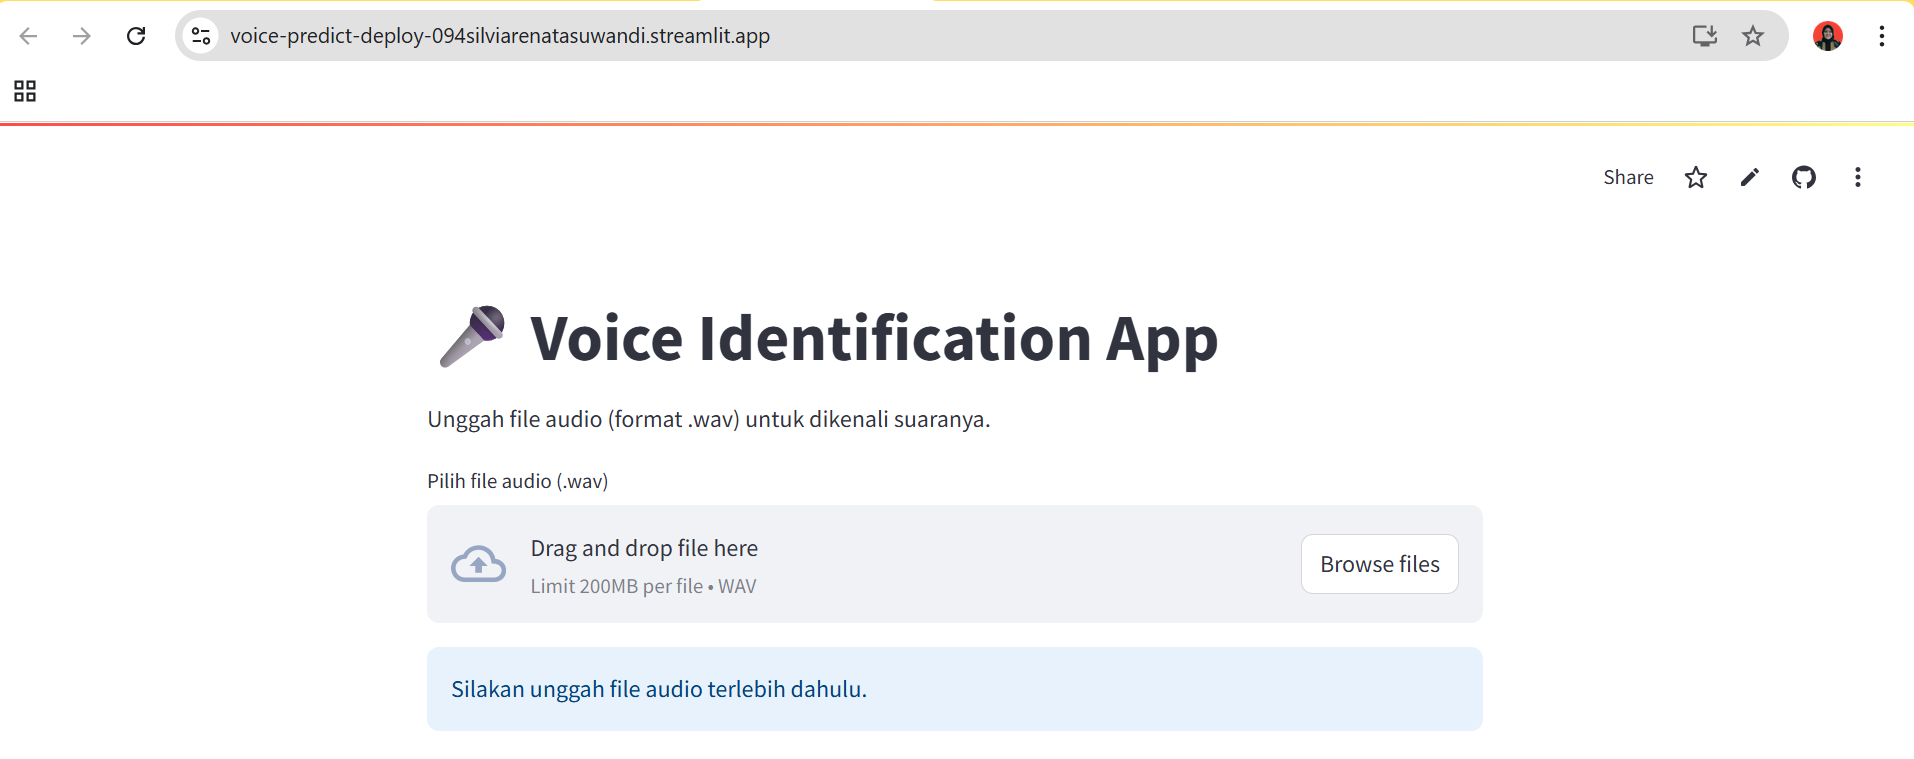


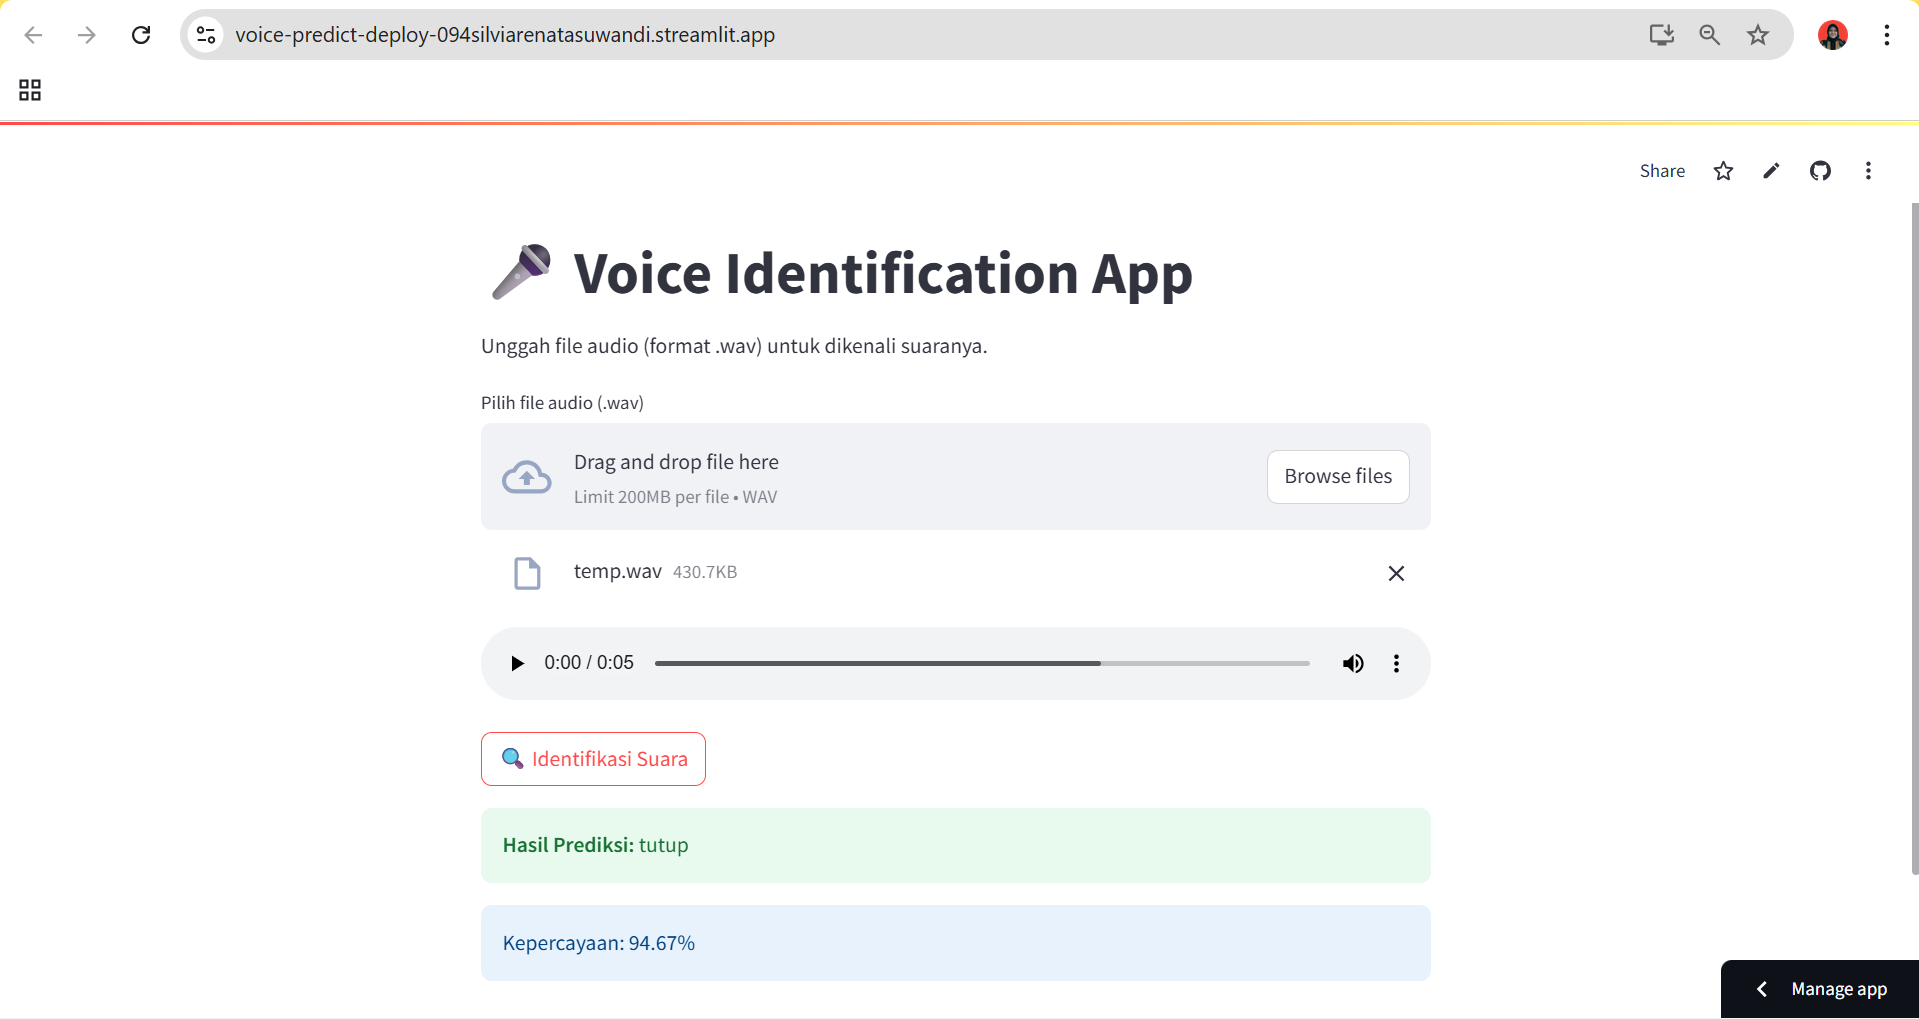